# ppidyom vs. IDyOM comparison

Runs **ppidyom** (R) and **IDyOM** (the original Common Lisp model) on the same input and
parameters, live, and shows the two outputs side by side.

Nothing is pre-computed. Pick parameters below and click **Run comparison** to check whether
the two engines agree.


In [1]:

import os, glob, subprocess, uuid, random
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown, HTML

# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT  = os.path.abspath(os.path.join(os.getcwd(), ".."))   # this notebook lives in examples/
LIVE_DIR   = os.path.join(REPO_ROOT, "examples", "_live_work")  # scratch dir, gitignored
DOCKER_IMG = "ppidyom-idyom-validation"                          # built by inst/validation/run_idyom_docker.sh
os.makedirs(LIVE_DIR, exist_ok=True)

# ── Toy corpus shared by both engines (same as tests/testthat/test-idyom-comparison.R) ──
ALPHABET   = ["A", "B", "C"]
PITCH_MAP  = {"A": 60, "B": 62, "C": 64}          # IDyOM only understands note pitches
TRAIN_SEQS = [
    list("ABCABCACB"),
    list("BCABACABC"),
]
PRESET_SEQS = {
    "x1  (A B A C A B A C A)": list("ABACABACA"),
    "x2  (B A B C A)":         list("BABCA"),
}
ESCAPE_CHOICES = ["A", "B", "C", "D", "X"]                       # ppidyom lambda names
IDYOM_ESCAPE   = {"A": "a", "B": "b", "C": "c", "D": "d", "X": "x"}  # -> IDyOM keyword
N = 3  # order bound, fixed here (ppidyom supports arbitrary N; see README_DEV.md)

# ── Colors (validated categorical palette; run dataviz's validate_palette.js to re-check) ──
COLOR_IDYOM    = "#2a78d6"  # IDyOM (Lisp) -- categorical slot 1
COLOR_PPIDYOM  = "#1baf7a"  # ppidyom (R)  -- categorical slot 2
COLOR_REF      = "#c3c2b7"  # muted reference / baseline lines
COLOR_GRID     = "#e1e0d9"  # hairline gridlines
COLOR_GOOD     = "#0ca30c"  # status: match
COLOR_CRITICAL = "#d03b3b"  # status: mismatch

print("Docker image found:" , subprocess.run(["docker", "image", "inspect", DOCKER_IMG],
      capture_output=True).returncode == 0)


Docker image found: True


## How it works

Every click runs two independent computations: ppidyom via `Rscript`, and real IDyOM via
Common Lisp inside a Docker container — no shortcuts or cached results.

Both get identical parameters (escape names are mapped between R and Lisp the same way
`test-idyom-comparison.R` validates), and the results are merged automatically.


In [2]:

R_TEMPLATE = r'''
suppressMessages(library(ppidyom))
suppressMessages(library(data.table))

alphabet <- c({alphabet})
model <- ppidyom:::ppidyomModel$new(
  N = {N}L, alphabet = alphabet,
  stm_exclusion        = {stm_exclusion},
  ltm_exclusion        = {ltm_exclusion},
  stm_update_exclusion = {stm_update_exclusion},
  ltm_update_exclusion = {ltm_update_exclusion},
  ltm_start_token       = FALSE
)

{train_calls}

x <- c({seq_r})
res <- model$predict_sequence(
  x, model_type = "{model}", ppm_type = "{ppm_type}",
  stm_lambda = "{stm_escape}", ltm_lambda = "{ltm_escape}",
  b = {b}, idyom_base = TRUE
)
observed <- data.table(index = seq_along(x), Event = x)
out <- res[observed, on = .(index, Event)][, .(index, Event, P, IC, Entropy)]
fwrite(out, "{out_csv}")
'''

LISP_TEMPLATE = '''\
(start-idyom)
(idyom-db:import-data :txt {train_file} "TRAIN_DATASET" 1001)
(idyom-db:import-data :txt {test_file} "TEST_DATASET" 2002)
(mvs:set-ltm-stm-bias {b})
(idyom:idyom 2002 '(cpitch) '(cpitch) :k 1 :models :{model} :detail 3 :pretraining-ids '(1001)
:stmo '(:escape :{stm_escape} :order-bound 3 :exclusion {stm_exclusion} :update-exclusion {stm_update_exclusion} :mixtures {mixtures})
:ltmo '(:escape :{ltm_escape} :order-bound 3 :exclusion {ltm_exclusion} :update-exclusion {ltm_update_exclusion} :mixtures {mixtures})
:output-path {out_dir} :overwrite nil :use-resampling-set-cache? nil :use-ltms-cache? nil)
(idyom-db:delete-dataset 1001)
(idyom-db:delete-dataset 2002)
(quit)
'''


In [3]:


def run_ppidyom(seq, model, stm_escape, ltm_escape, stm_exclusion, ltm_exclusion,
                stm_update_exclusion, ltm_update_exclusion, mixtures, b):
    work = os.path.join(LIVE_DIR, f"r_{uuid.uuid4().hex[:8]}")
    os.makedirs(work, exist_ok=True)
    out_csv = os.path.join(work, "out.csv")

    train_calls = ""
    if model != "stm":
        train_calls = "\n".join(
            'model$train_sequence(c(%s))' % ", ".join(f'"{s}"' for s in tseq)
            for tseq in TRAIN_SEQS
        )

    script = R_TEMPLATE.format(
        alphabet=", ".join(f'"{a}"' for a in ALPHABET), N=N,
        stm_exclusion=str(stm_exclusion).upper(), ltm_exclusion=str(ltm_exclusion).upper(),
        stm_update_exclusion=str(stm_update_exclusion).upper(),
        ltm_update_exclusion=str(ltm_update_exclusion).upper(),
        train_calls=train_calls, seq_r=", ".join(f'"{s}"' for s in seq),
        model=model, ppm_type="interpolation" if mixtures else "backoff",
        stm_escape=stm_escape, ltm_escape=ltm_escape, b=b, out_csv=out_csv,
    )
    script_path = os.path.join(work, "run.R")
    with open(script_path, "w") as f:
        f.write(script)

    result = subprocess.run(["Rscript", script_path], capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError("ppidyom (R) failed:\n" + result.stderr)
    df = pd.read_csv(out_csv)
    return df.rename(columns={"P": "P_ppidyom", "IC": "IC_ppidyom", "Entropy": "Entropy_ppidyom"})


def run_idyom(seq, model, stm_escape, ltm_escape, stm_exclusion, ltm_exclusion,
              stm_update_exclusion, ltm_update_exclusion, mixtures, b):
    work = os.path.join(LIVE_DIR, f"idyom_{uuid.uuid4().hex[:8]}")
    inputs, outputs = os.path.join(work, "inputs"), os.path.join(work, "outputs")
    os.makedirs(inputs, exist_ok=True)
    os.makedirs(outputs, exist_ok=True)

    def write_txt(seqs, path):
        with open(path, "w") as f:
            for s in seqs:
                f.write(" ".join(str(PITCH_MAP[c]) for c in s) + "\n")

    write_txt(TRAIN_SEQS, os.path.join(inputs, "train.txt"))
    write_txt([seq], os.path.join(inputs, "test.txt"))

    lb = lambda v: "t" if v else "nil"
    lisp = LISP_TEMPLATE.format(
        train_file='"/work/inputs/train.txt"', test_file='"/work/inputs/test.txt"',
        b=b, model=model, stm_escape=IDYOM_ESCAPE[stm_escape], ltm_escape=IDYOM_ESCAPE[ltm_escape],
        stm_exclusion=lb(stm_exclusion), ltm_exclusion=lb(ltm_exclusion),
        stm_update_exclusion=lb(stm_update_exclusion), ltm_update_exclusion=lb(ltm_update_exclusion),
        mixtures=lb(mixtures), out_dir='"/work/outputs"',
    )
    lisp_path = os.path.join(work, "compute.lisp")
    with open(lisp_path, "w") as f:
        f.write(lisp)

    cmd = ["docker", "run", "--rm", "-v", f"{work}:/work", "-w", "/work", DOCKER_IMG,
           "sbcl", "--dynamic-space-size", "8192", "--noinform", "--load", "/work/compute.lisp"]
    result = subprocess.run(cmd, capture_output=True, text=True)
    dat_files = glob.glob(os.path.join(outputs, "*.dat"))
    if not dat_files:
        raise RuntimeError("IDyOM run failed:\n" + result.stdout + result.stderr)

    df = pd.read_csv(dat_files[0], sep=r"\s+", engine="python")
    ic_col   = "cpitch.ic"          if "cpitch.ic"          in df.columns else "ic"
    ent_col  = "cpitch.entropy"     if "cpitch.entropy"     in df.columns else "entropy"
    prob_col = "cpitch.probability" if "cpitch.probability" in df.columns else "probability"
    if "note.id" in df.columns:
        df = df.sort_values("note.id").reset_index(drop=True)

    return pd.DataFrame({
        "index": range(1, len(df) + 1), "Event": seq,
        "P_idyom": df[prob_col].astype(float),
        "IC_idyom": df[ic_col].astype(float),
        "Entropy_idyom": df[ent_col].astype(float),
    })


def compare(seq, **params):
    pp  = run_ppidyom(seq, **params)
    idy = run_idyom(seq, **params)
    merged = pp.merge(idy, on=["index", "Event"])
    merged["IC_diff"] = (merged.IC_ppidyom - merged.IC_idyom).abs()
    merged["H_diff"]  = (merged.Entropy_ppidyom - merged.Entropy_idyom).abs()
    return merged[["index", "Event", "P_ppidyom", "P_idyom",
                   "IC_ppidyom", "IC_idyom", "IC_diff",
                   "Entropy_ppidyom", "Entropy_idyom", "H_diff"]]


## 🎛 Set the parameters

Each widget controls one parameter: model type, escape method (STM/LTM), exclusion /
update-exclusion, mixtures vs. backoff, the blend bias `b`, and the test sequence (a preset
or your own A/B/C string).

Click **▶ Run comparison** to compare with the current settings, or **🎲 Randomize + Run**
to try an arbitrary combination.


In [4]:

w_model      = widgets.Dropdown(options=["stm", "ltm", "both", "ltm+", "both+"], value="both", description="model:")
w_stm_escape = widgets.Dropdown(options=ESCAPE_CHOICES, value="C", description="STM escape:")
w_ltm_escape = widgets.Dropdown(options=ESCAPE_CHOICES, value="C", description="LTM escape:")
w_stm_excl   = widgets.Checkbox(value=True,  description="STM exclusion")
w_stm_upd    = widgets.Checkbox(value=False, description="STM update-exclusion")
w_ltm_excl   = widgets.Checkbox(value=True,  description="LTM exclusion")
w_ltm_upd    = widgets.Checkbox(value=False, description="LTM update-exclusion")
w_mixtures   = widgets.Checkbox(value=True,  description="mixtures (interpolation)")
w_b          = widgets.IntSlider(value=7, min=1, max=10, description="b (bias):")
w_seq_preset = widgets.Dropdown(options=list(PRESET_SEQS.keys()) + ["custom..."],
                                 value=list(PRESET_SEQS.keys())[0], description="Sequence:")
w_seq_custom = widgets.Text(value="", placeholder="e.g. A B C A B  (A/B/C only)", description="Custom:")
btn_run      = widgets.Button(description="▶ Run comparison", button_style="primary")
btn_random   = widgets.Button(description="🎲 Randomize + Run", button_style="warning")
out          = widgets.Output()


def get_seq():
    if w_seq_preset.value == "custom...":
        raw = w_seq_custom.value.upper().replace(",", " ").split()
        seq = [c for c in raw if c in ALPHABET]
        if not seq:
            raise ValueError("Custom sequence must contain letters from A/B/C.")
        return seq
    return PRESET_SEQS[w_seq_preset.value]


def current_params():
    return dict(
        model=w_model.value, stm_escape=w_stm_escape.value, ltm_escape=w_ltm_escape.value,
        stm_exclusion=w_stm_excl.value, ltm_exclusion=w_ltm_excl.value,
        stm_update_exclusion=w_stm_upd.value, ltm_update_exclusion=w_ltm_upd.value,
        mixtures=w_mixtures.value, b=w_b.value,
    )


def render(seq, params, merged):
    display(Markdown(
        f"#### model=`{params['model']}`  &nbsp; STM: escape=`{params['stm_escape']}` "
        f"excl=`{params['stm_exclusion']}` upd-excl=`{params['stm_update_exclusion']}`  &nbsp; "
        f"LTM: escape=`{params['ltm_escape']}` excl=`{params['ltm_exclusion']}` "
        f"upd-excl=`{params['ltm_update_exclusion']}`  &nbsp; "
        f"mixtures=`{params['mixtures']}` b=`{params['b']}`  &nbsp; sequence=`{' '.join(seq)}`"
    ))

    max_ic_diff = merged.IC_diff.max()
    max_h_diff  = merged.H_diff.max()
    is_match = max(max_ic_diff, max_h_diff) < 1e-3
    banner_color = COLOR_GOOD if is_match else COLOR_CRITICAL
    banner_text  = "MATCH" if is_match else "MISMATCH"
    display(HTML(
        f'<div style="background:{banner_color};color:white;display:inline-block;'
        f'padding:10px 18px;border-radius:6px;font-size:1.15em;font-weight:700;'
        f'font-family:system-ui,sans-serif;margin:6px 0 12px 0;">'
        f'{"✓" if is_match else "✗"} {banner_text} '
        f'&nbsp; max |Δ IC| = {max_ic_diff:.1e} bits &nbsp;·&nbsp; '
        f'max |Δ entropy| = {max_h_diff:.1e} bits</div>'
    ))

    fmt_cols = ["P_ppidyom", "P_idyom", "IC_ppidyom", "IC_idyom", "IC_diff",
                "Entropy_ppidyom", "Entropy_idyom", "H_diff"]
    # Light column-group tints (not data-driven) so each metric's ppidyom/IDyOM
    # pair is easy to eyeball side by side; diff columns stay untinted.
    display(merged.style.format({c: "{:.4f}" for c in fmt_cols})
                  .set_properties(subset=["P_ppidyom", "P_idyom"], **{"background-color": "#eef4fc"})
                  .set_properties(subset=["IC_ppidyom", "IC_idyom"], **{"background-color": "#eaf7f1"})
                  .set_properties(subset=["Entropy_ppidyom", "Entropy_idyom"],
                                   **{"background-color": "#fdf6e8"}))

    fig, (ax_ic, ax_h) = plt.subplots(1, 2, figsize=(11, 4.2), facecolor="white")

    # Per-timestep overlay. ppidyom is drawn as a hollow ring exactly on top of
    # IDyOM's filled marker -- when they match, the ring sits dead-center on
    # the dot with no offset to eyeball.
    for ax, ycol_pp, ycol_id, title in [
        (ax_ic, "IC_ppidyom", "IC_idyom", "Information content (bits)"),
        (ax_h,  "Entropy_ppidyom", "Entropy_idyom", "Entropy (bits)"),
    ]:
        ax.plot(merged["index"], merged[ycol_id], "-", color=COLOR_IDYOM, linewidth=2.5,
                 marker="o", markersize=9, zorder=2, label="IDyOM (Lisp)")
        ax.plot(merged["index"], merged[ycol_pp], linestyle="none", marker="o", markersize=14,
                 markerfacecolor="none", markeredgecolor=COLOR_PPIDYOM, markeredgewidth=2.5,
                 zorder=3, label="ppidyom (R)")
        ax.set_xlabel("timestep"); ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xticks(merged["index"]); ax.set_xticklabels(merged["Event"])
        ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.legend(frameon=False, fontsize=9, loc="best")

    plt.tight_layout()
    plt.show()


def on_run(_):
    with out:
        clear_output(wait=True)
        try:
            seq, params = get_seq(), current_params()
            print("Running ppidyom (R) and IDyOM (live, Docker) ...")
            merged = compare(seq, **params)
            clear_output(wait=True)
            render(seq, params, merged)
        except Exception as e:
            print("Error:", e)


def on_random(_, max_attempts=10):
    # Retries a few times in case of a transient error (e.g. a Docker hiccup).
    for attempt in range(max_attempts):
        w_model.value      = random.choice(["stm", "ltm", "both", "ltm+", "both+"])
        w_stm_escape.value = random.choice(ESCAPE_CHOICES)
        w_ltm_escape.value = random.choice(ESCAPE_CHOICES)
        w_stm_excl.value   = random.choice([True, False])
        w_stm_upd.value    = random.choice([True, False])
        w_ltm_excl.value   = random.choice([True, False])
        w_ltm_upd.value    = random.choice([True, False])
        w_mixtures.value   = random.choice([True, False])
        w_b.value          = random.choice([1, 3, 7, 10])
        w_seq_preset.value = random.choice(list(PRESET_SEQS.keys()))
        params = current_params()
        try:
            seq = get_seq()
            merged = compare(seq, **params)
        except Exception:
            continue
        with out:
            clear_output(wait=True)
            render(seq, params, merged)
        return
    with out:
        clear_output(wait=True)
        print(f"Couldn't find a working random combo in {max_attempts} tries -- try again.")


btn_run.on_click(on_run)
btn_random.on_click(on_random)

display(widgets.VBox([
    widgets.HBox([w_model, w_mixtures, w_b]),
    widgets.HBox([w_stm_escape, w_stm_excl, w_stm_upd]),
    widgets.HBox([w_ltm_escape, w_ltm_excl, w_ltm_upd]),
    widgets.HBox([w_seq_preset, w_seq_custom]),
    widgets.HBox([btn_run, btn_random]),
    out,
]))


## Does it hold up across many combinations?

The cell below runs a batch of random parameter combinations and plots the worst-case error
across all of them, to check that agreement isn't limited to a few hand-picked settings.


[1/100] ltm+/se=C/le=B           max_IC_diff=1.08e-07  max_H_diff=9.93e-08
[2/100] ltm/se=B/le=X            max_IC_diff=8.21e-08  max_H_diff=9.93e-08
[3/100] both/se=X/le=B           max_IC_diff=4.84e-07  max_H_diff=1.17e-07
[4/100] stm/se=D/le=B            max_IC_diff=1.06e-07  max_H_diff=1.01e-07
[5/100] both/se=D/le=X           max_IC_diff=3.49e-07  max_H_diff=1.28e-07
[6/100] ltm/se=B/le=D            max_IC_diff=2.50e-07  max_H_diff=9.93e-08
[7/100] stm/se=D/le=C            max_IC_diff=9.49e-08  max_H_diff=9.93e-08
[8/100] stm/se=X/le=D            max_IC_diff=1.18e-07  max_H_diff=2.20e-07
[9/100] ltm+/se=D/le=D           max_IC_diff=3.41e-07  max_H_diff=9.93e-08
[10/100] both+/se=A/le=A          max_IC_diff=2.35e-07  max_H_diff=1.52e-07
[11/100] both/se=D/le=X           max_IC_diff=3.60e-07  max_H_diff=1.98e-07
[12/100] both+/se=C/le=B          max_IC_diff=1.40e-07  max_H_diff=1.01e-07
[13/100] ltm+/se=A/le=A           max_IC_diff=1.08e-07  max_H_diff=1.01e-07
[14/100] both/se=X/le

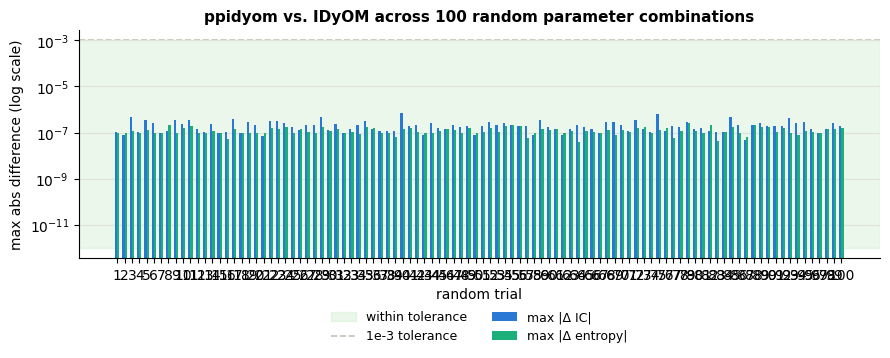

In [5]:

random.seed()  # fresh randomness each run; set a fixed seed for reproducible results
N_TRIALS = 100

def random_params():
    return dict(
        model=random.choice(["stm", "ltm", "both", "ltm+", "both+"]),
        stm_escape=random.choice(ESCAPE_CHOICES), ltm_escape=random.choice(ESCAPE_CHOICES),
        stm_exclusion=random.choice([True, False]), ltm_exclusion=random.choice([True, False]),
        stm_update_exclusion=random.choice([True, False]), ltm_update_exclusion=random.choice([True, False]),
        mixtures=random.choice([True, False]), b=random.choice([1, 3, 7, 10]),
    )

rows = []
i = 0
attempts = 0
while i < N_TRIALS and attempts < N_TRIALS * 3:
    attempts += 1
    params = random_params()
    seq = random.choice(list(PRESET_SEQS.values()))
    try:
        merged = compare(seq, **params)
    except Exception:
        continue  # skip and redraw on a transient failure
    i += 1
    rows.append({
        "trial": i,
        "config": f"{params['model']}/se={params['stm_escape']}/le={params['ltm_escape']}",
        "max_IC_diff": merged.IC_diff.max(),
        "max_H_diff": merged.H_diff.max(),
    })
    print(f"[{i}/{N_TRIALS}] {rows[-1]['config']:<24} "
          f"max_IC_diff={rows[-1]['max_IC_diff']:.2e}  max_H_diff={rows[-1]['max_H_diff']:.2e}")

sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 3.8), facecolor="white")
ax.axhspan(1e-12, 1e-3, color=COLOR_GOOD, alpha=0.08, zorder=0, label="within tolerance")
ax.bar(sweep["trial"] - 0.15, sweep["max_IC_diff"], width=0.3, color=COLOR_IDYOM,
       label="max |Δ IC|", zorder=2)
ax.bar(sweep["trial"] + 0.15, sweep["max_H_diff"],  width=0.3, color=COLOR_PPIDYOM,
       label="max |Δ entropy|", zorder=2)
ax.axhline(1e-3, color=COLOR_REF, linestyle="--", linewidth=1.2, zorder=1, label="1e-3 tolerance")
ax.set_yscale("log")
ax.set_xlabel("random trial"); ax.set_ylabel("max abs difference (log scale)")
ax.set_title(f"ppidyom vs. IDyOM across {N_TRIALS} random parameter combinations",
             fontsize=11, fontweight="bold")
ax.set_xticks(sweep["trial"])
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8, zorder=0)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.show()

worst_ic, worst_h = sweep.max_IC_diff.max(), sweep.max_H_diff.max()
worst = max(worst_ic, worst_h)
sweep_match = worst < 1e-3
banner_color = COLOR_GOOD if sweep_match else COLOR_CRITICAL
ratio = (1e-3 / worst) if worst > 0 else float("inf")
note = (f"— {ratio:,.0f}x inside the 1e-3 tolerance." if sweep_match
        else f"— {1/ratio:,.0f}x OVER the 1e-3 tolerance.")
display(HTML(
    f'<div style="background:{banner_color};color:white;display:inline-block;'
    f'padding:10px 18px;border-radius:6px;font-size:1.1em;font-weight:700;'
    f'font-family:system-ui,sans-serif;margin-top:8px;">'
    f'{"✓" if sweep_match else "✗"} Worst case across all {N_TRIALS} random trials: '
    f'Δ IC = {worst_ic:.1e} bits, Δ entropy = {worst_h:.1e} bits {note}</div>'
))
